# Assignment: Linear Models


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A model is linear when the output forms a straight line based on a weighted sum of inputs. The model is linear in its parameters.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)

With intercept included, the dummy variable coefficient represetns the difference in y relative to the reference category. Without the intercept, dummy coefficient represents the mean outcome for that category.

3. Can linear regression be used for classification? Explain why, or why not.

Yes, techincally you can use linear regression for classification by setting a threshold on the continuous output, but most of the time, there are more appropriate methods for classification.

4. What are signs that your linear model is over-fitting?

High training accuracy and low test performance, high variance, and unstable coefficients are all signs that a linear model is overfitting.

5. Clearly explain multi-colinearity using the two-stage least squares technique.

You first regress one predictor (x1) on the other predictors and the residual v is the part of x1 not explained by other variables. Then, you regress y on the residual and if x1 is highly collinear with the other variables, the residual v will be very small leading to unstable and high variance estimates of B1.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

You can transform your features with polynomial terms, log transforming, interactions, etc. and the model remain linear in its parameters.

7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

intercept - the predicted value of y when all x's are 0

slope - the expected change in y for a one unit increase in xi

dummy variable - With intercept, the dummy variable coefficient represetns the difference in y relative to the reference category. Without the intercept, dummy coefficient represents the mean outcome for that category.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.
2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [7]:
import pandas as pd

Q2 = pd.read_csv('./data/Q1_clean.csv')
Q2.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [8]:
#Q2.1
Q2.groupby('Neighbourhood ')['Price'].mean().sort_values(ascending=False)

,Price
Neighbourhood,
Manhattan,183.664286
Staten Island,146.166667
Brooklyn,127.747378
Queens,96.857233
Bronx,75.276498


<Axes: xlabel='Price', ylabel='Density'>

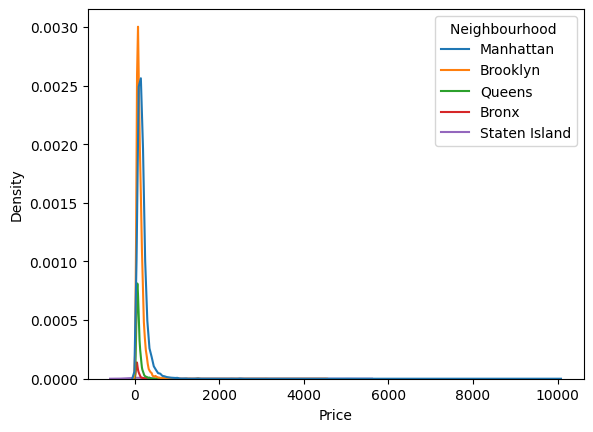

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(data=Q2, x='Price', hue='Neighbourhood ')

<Axes: xlabel='log_price', ylabel='Density'>

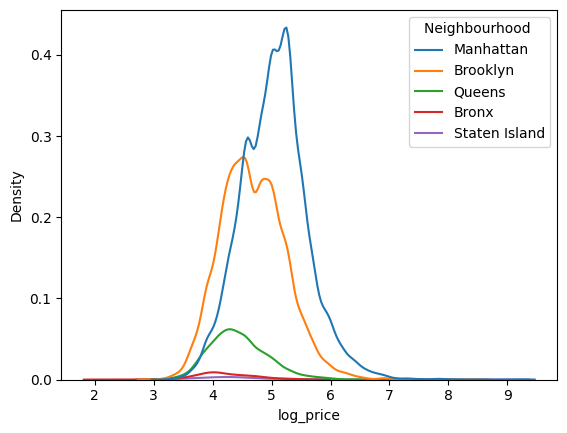

In [11]:
import numpy as np

Q2['log_price'] = np.log(Q2['Price'])
sns.kdeplot(data=Q2, x='log_price', hue='Neighbourhood ')

In [22]:
#Q2.2
import statsmodels.api as sm

Q2_dummy = pd.get_dummies(Q2['Neighbourhood '], drop_first=True)

X = Q2_dummy
y = Q2['Price']

model_no_intercept = sm.OLS(y, X).fit()
model_no_intercept.summary()

#each coefficient is the mean price of that neighborhood since there is no intercept
#so, regression coefficients = group means

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  Price   R-squared (uncentered):                   0.541
Model:                            OLS   Adj. R-squared (uncentered):              0.541
Method:                 Least Squares   F-statistic:                              6517.
Date:                Tue, 24 Mar 2026   Prob (F-statistic):                        0.00
Time:                        20:41:59   Log-Likelihood:                     -1.4177e+05
No. Observations:               22153   AIC:                                  2.835e+05
Df Residuals:                   22149   BIC:                                  2.836e+05
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Brooklyn        127.7474      1.580     80.853      0.000     124.650     130.844
Manhattan       183.6643      1.342    136.852      0.000     181.034     186.295
Queens           96.8572      3.650     26.534      0.000      89.702     104.012
Staten Island   146.1667     14.856      9.839      0.000     117.048     175.285
==============================================================================
Omnibus:                    51139.138   Durbin-Watson:                   1.734
Prob(Omnibus):                  0.000   Jarque-Bera (JB):       1178859869.179
Skew:                          22.107   Prob(JB):                         0.00
Kurtosis:                    1132.244   Cond. No.                         11.1
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [23]:
#Q2.3
dummies = pd.get_dummies(Q2['Neighbourhood '], drop_first=True, dtype=float)

X = sm.add_constant(dummies)
y = Q2['Price'].astype(float)

model_intercept = sm.OLS(y, X).fit()
print(model_intercept.summary())

#you have to drop on category to avoid multicollinearity
#the intercept is the average price of the omitted neighborhood
#to interpret coefficients, each one is the difference in average price between that neighborhood and the reference group
#to get back to the coefficients from part 2 just add the intercept back

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        20:42:03   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

In [24]:
#Q2.4
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

Q2.columns = Q2.columns.str.strip()

Q2['Price'] = pd.to_numeric(Q2['Price'], errors='coerce')
Q2['Review Scores Rating'] = pd.to_numeric(Q2['Review Scores Rating'], errors='coerce')

X = pd.get_dummies(Q2['Neighbourhood'], drop_first=True, dtype=float)
X['Rating'] = Q2['Review Scores Rating']

y = Q2['Price']

data = pd.concat([X, y], axis=1).dropna()
X = data.drop(columns=['Price'])
y = data['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = sm.OLS(y_train, sm.add_constant(X_train)).fit()

y_pred = model.predict(sm.add_constant(X_test))

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = model.rsquared

print("R^2:", r2)
print("RMSE:", rmse)
print(model.summary())

#R^2 = 0.0508 and RMSE = 140.92
#The coefficient for Review Score Rating is 1.2119
#The most expensive kind of property you can rent would be in Manhattan since it has the largest coefficient

R^2: 0.05084134919122241
RMSE: 140.91821103729342
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     189.8
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          1.33e-197
Time:                        20:48:12   Log-Likelihood:            -1.1348e+05
No. Observations:               17722   AIC:                         2.270e+05
Df Residuals:                   17716   BIC:                         2.270e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [26]:
#Q2.5
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X = pd.get_dummies(Q2[['Neighbourhood', 'Property Type']], drop_first=True, dtype=float)
X['Rating'] = Q2['Review Scores Rating']

y = Q2['Price']

# Drop missing
data = pd.concat([X, y], axis=1).dropna()
X = data.drop(columns=['Price'])
y = data['Price']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit
model = sm.OLS(y_train, sm.add_constant(X_train)).fit()

# Predict
y_pred = model.predict(sm.add_constant(X_test))

# Metrics (TEST SET)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test R^2:", r2)
print("Test RMSE:", rmse)
print(model.summary())

#R^2 = 0.054 and RMSE = 140.3
#The coefficient for Review Score Rating is 1.201
#The most expensive kind of property type you can rent would be a Loft in Manhattan since they both have the highest coefficients

Test R^2: 0.054242713551245325
Test RMSE: 140.30266238276283
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     51.46
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          2.52e-218
Time:                        20:52:52   Log-Likelihood:            -1.1339e+05
No. Observations:               17722   AIC:                         2.268e+05
Df Residuals:                   17699   BIC:                         2.270e+05
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

Q2.6

The coefficient on Review Scores Rating changes from Part 4 to Part 5 because including Property Type controls for an important confounding variable. In Part 4, the coefficient captured both the effect of ratings and the effect of property type (which correlates with rating). In Part 5, the coefficient represents the true partial effect of ratings on price, holding neighbourhood and property type constant.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

In [30]:
#Q3.1
import pandas as pd

Q3 = pd.read_csv('./data/cars_hw.csv')
Q3['Make'] = Q3['Make'].str.lower()
Q3['Transmission_Type'] = Q3['Transmission_Type'].str.lower()
Q3.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,automatic,657000
1,2,hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,manual,682000
2,3,honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,manual,793000
3,4,renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,manual,414000
4,5,hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,manual,515000


In [35]:
#Q3.2
Q3['Price'].describe()

,Price
count,9.760000e+02
mean,7.410195e+05
std,3.673234e+05
min,1.880000e+05
25%,4.757500e+05
50%,6.665000e+05
75%,8.830000e+05
max,2.941000e+06


<Axes: xlabel='Price', ylabel='Density'>

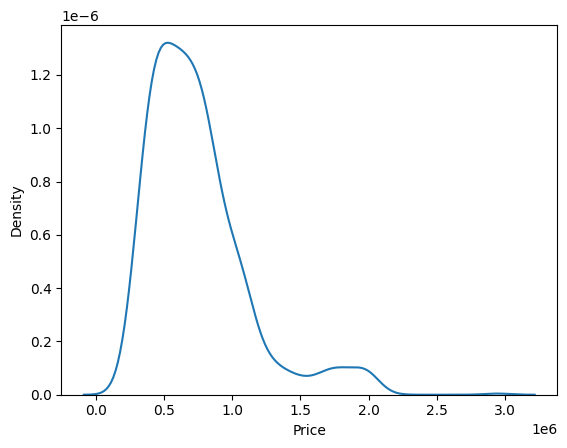

In [36]:
sns.kdeplot(data=Q3, x='Price')

In [38]:
price_by_make = Q3.groupby('Make')['Price'].describe()
print(price_by_make)

               count          mean           std        min        25%  \
Make                                                                     
chevrolet        6.0  4.535000e+05  2.466064e+05   267000.0   288500.0   
datsun           3.0  2.896667e+05  1.050397e+04   279000.0   284500.0   
ford            52.0  7.211731e+05  1.409277e+05   290000.0   635000.0   
honda           73.0  7.989726e+05  2.665091e+05   316000.0   581000.0   
hyundai        305.0  6.918918e+05  2.791597e+05   248000.0   485000.0   
jeep             4.0  1.499500e+06  1.525134e+05  1290000.0  1447500.0   
kia              8.0  1.614750e+06  1.190567e+05  1369000.0  1579000.0   
mahindra        18.0  1.100167e+06  1.755493e+05   796000.0  1037000.0   
maruti suzuki  293.0  5.887850e+05  2.160199e+05   237000.0   411000.0   
mg motors       35.0  1.869457e+06  1.216611e+05  1589000.0  1786500.0   
nissan           4.0  8.842500e+05  2.895599e+05   475000.0   782500.0   
renault         68.0  6.625735e+05  2.

<Axes: xlabel='Price', ylabel='Density'>

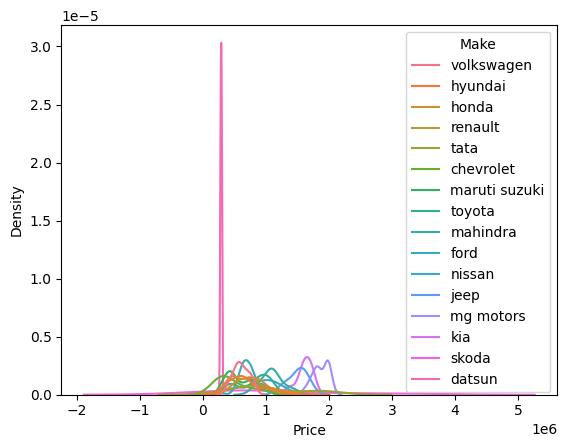

In [39]:
sns.kdeplot(data=Q3, x='Price', hue='Make', common_norm=False)

Prices to be heavily skewed right and some of the most expensive brands are jeep, kia, and mg motors.

In [42]:
#Q3.3
from sklearn.model_selection import train_test_split

train_cars, test_cars = train_test_split(Q3, test_size=0.2, random_state=42)

In [44]:
#Q3.4
train, test = train_test_split(Q3, test_size=0.2, random_state=42)
y_train = train['Price']
y_test = test['Price']

#Numeric-only model
num_vars = ['Seating_Capacity', 'Mileage_Run', 'Make_Year']
X_train_num = sm.add_constant(train[num_vars])
X_test_num = sm.add_constant(test[num_vars])
model_num = sm.OLS(y_train, X_train_num).fit()
y_test_pred_num = model_num.predict(X_test_num)
r2_test_num = 1 - np.sum((y_test - y_test_pred_num)**2)/np.sum((y_test - y_test.mean())**2)
rmse_test_num = np.sqrt(mean_squared_error(y_test, y_test_pred_num))

#Categorical-only model
cat_vars = ['Color','Body_Type','Make','Fuel_Type','Transmission','Transmission_Type']
X_train_cat = pd.get_dummies(train[cat_vars], drop_first=True, dtype=float)
X_test_cat = pd.get_dummies(test[cat_vars], drop_first=True, dtype=float)
X_test_cat = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0)
X_train_cat = sm.add_constant(X_train_cat)
X_test_cat = sm.add_constant(X_test_cat)
model_cat = sm.OLS(y_train, X_train_cat).fit()
y_test_pred_cat = model_cat.predict(X_test_cat)
r2_test_cat = 1 - np.sum((y_test - y_test_pred_cat)**2)/np.sum((y_test - y_test.mean())**2)
rmse_test_cat = np.sqrt(mean_squared_error(y_test, y_test_pred_cat))

#Combined model
X_train_all = sm.add_constant(pd.concat([train[num_vars], pd.get_dummies(train[cat_vars], drop_first=True, dtype=float)], axis=1))
X_test_all = sm.add_constant(pd.concat([test[num_vars], pd.get_dummies(test[cat_vars], drop_first=True, dtype=float)], axis=1))
X_test_all = X_test_all.reindex(columns=X_train_all.columns, fill_value=0)
model_all = sm.OLS(y_train, X_train_all).fit()
y_test_pred_all = model_all.predict(X_test_all)
r2_test_all = 1 - np.sum((y_test - y_test_pred_all)**2)/np.sum((y_test - y_test.mean())**2)
rmse_test_all = np.sqrt(mean_squared_error(y_test, y_test_pred_all))

#Print results
print("Numeric-only model:     R² =", round(r2_test_num,3), "RMSE =", round(rmse_test_num,2))
print("Categorical-only model: R² =", round(r2_test_cat,3), "RMSE =", round(rmse_test_cat,2))
print("Combined model:         R² =", round(r2_test_all,3), "RMSE =", round(rmse_test_all,2))

Numeric-only model:     R² = 0.294 RMSE = 284546.95
Categorical-only model: R² = 0.708 RMSE = 182974.74
Combined model:         R² = 0.822 RMSE = 142892.74


The combined model performs the best as it returned the highest R^2 value of 0.822, just better than the categorical model at 0.708, and it has the lowest RMSE. The joint model performs better because it combines the strengths of numeric and categorical variables, giving substantially better predictive accuracy than either model alone.

In [49]:
#Q3.5
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

train, test = train_test_split(Q3, test_size=0.2, random_state=42)
y_train = train['Price']
y_test = test['Price']

num_vars = ['Seating_Capacity', 'Mileage_Run', 'Make_Year']
X_train_num = train[num_vars]
X_test_num = test[num_vars]

degrees = [1, 2, 3, 4, 5]
r2_train_list = []
r2_test_list = []
rmse_train_list = []
rmse_test_list = []

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_num)
    X_test_poly = poly.transform(X_test_num)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    r2_train = model.score(X_train_poly, y_train)
    r2_test = model.score(X_test_poly, y_test)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    r2_train_list.append(r2_train)
    r2_test_list.append(r2_test)
    rmse_train_list.append(rmse_train)
    rmse_test_list.append(rmse_test)

    print(f"Degree {d}: Train R²={r2_train:.3f}, Test R²={r2_test:.3f}, Train RMSE={rmse_train:.2f}, Test RMSE={rmse_test:.2f}")

best_idx = np.argmax(r2_test_list)
best_degree = degrees[best_idx]
best_r2_test = r2_test_list[best_idx]
best_rmse_test = rmse_test_list[best_idx]

print("\nBest numeric polynomial model:")
print(f"Degree: {best_degree}, Test R²={best_r2_test:.3f}, Test RMSE={best_rmse_test:.2f}")

combined_r2_test = 0.822  # from part 4
combined_rmse_test = 142893.0  # from part 4

print("\nComparison to combined model (numeric + categorical) from part 4:")
print(f"Numeric-poly best model: R²={best_r2_test:.3f}, RMSE={best_rmse_test:.2f}")
print(f"Combined model: R²={combined_r2_test:.3f}, RMSE={combined_rmse_test:.2f}")
print(f"Difference in R²: {combined_r2_test - best_r2_test:.3f}")
print(f"Difference in RMSE: {best_rmse_test - combined_rmse_test:.2f}")

Degree 1: Train R²=0.314, Test R²=0.294, Train RMSE=309338.37, Test RMSE=284546.95
Degree 2: Train R²=0.348, Test R²=0.327, Train RMSE=301621.83, Test RMSE=277849.35
Degree 3: Train R²=0.341, Test R²=0.312, Train RMSE=303385.03, Test RMSE=281003.61
Degree 4: Train R²=0.349, Test R²=0.308, Train RMSE=301556.19, Test RMSE=281751.62
Degree 5: Train R²=0.346, Test R²=0.291, Train RMSE=302220.38, Test RMSE=285141.53

Best numeric polynomial model:
Degree: 2, Test R²=0.327, Test RMSE=277849.35

Comparison to combined model (numeric + categorical) from part 4:
Numeric-poly best model: R²=0.327, RMSE=277849.35
Combined model: R²=0.822, RMSE=142893.00
Difference in R²: 0.495
Difference in RMSE: 134956.35


Train R^2 slightly increases with degree (from 0.314 → 0.349), meaning the model fits the training data better with higher-degree polynomials. Test R^2 peaks at degree 2 (0.327), then decreases for higher degrees. Test RMSE is lowest at degree 2 (277,849) and increases again for higher degrees.

In our results, R^2 never goes negative, but it starts to decline after degree 2.

Our best numeric polynomial model had degree of 2, test R^2 of 0.327, and test RMSE of 277,849.

Difference:

R^2: 0.822 − 0.327 = 0.495 → combined model explains almost 50% more variance
RMSE: 277,849 − 142,893 = 134,956 → combined model predicts much more accurately

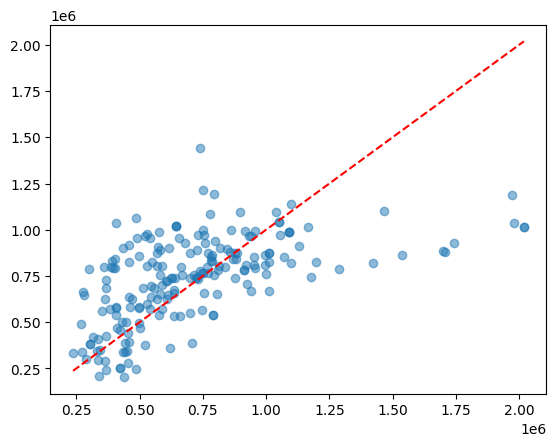

In [50]:
# --- Predicted vs True Prices plot ---
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')

#the true values do roughly ine up along the diagonal

<Axes: xlabel='Price', ylabel='Density'>

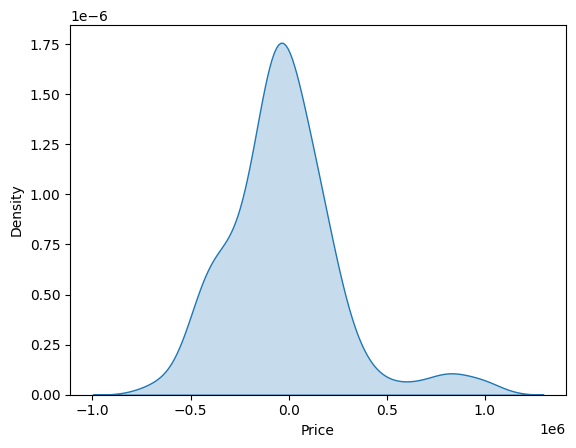

In [51]:
residuals = y_test - y_test_pred
sns.kdeplot(residuals, fill=True)

#the residuals look roughly bell shaped around zero

Strengths: high predictive power, capture key categorcal effects, residuals roughly normal, interpretable

Weaknesses: extreme values harder to predict, linear assumptions, potnetial overfitting with many categorical dummy variables

**Q4.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.
2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.
3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.
4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.
5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.
6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.

Answers on paper in folder.